# Lecture 4 — Scatter & Bubble Charts
## Preattentive Attributes & Colour

> **Dataset:** Gapminder — GDP per capita, Life Expectancy, Population. Source: Gapminder Foundation ([gapminder.org](https://www.gapminder.org/))

> **Source of figures:** Knaflic, C. N. (2015). *Storytelling with data*. Wiley.


## Model Answer Review From Week 03

---
## Design Principles - Part I: Pre-attentive Attributes


### You see with your brain, not just your eyes

> 💡 **Iconic memory processes your visual field before you consciously see anything — within 250 milliseconds. Preattentive attributes act at this level. When we use them correctly, we can make the audience see exactly what we want before they even realise they are looking**


*Count the 3s — no visual cues: requires slow conscious search [ FIGURE 4.2 — p.102 ]*

> 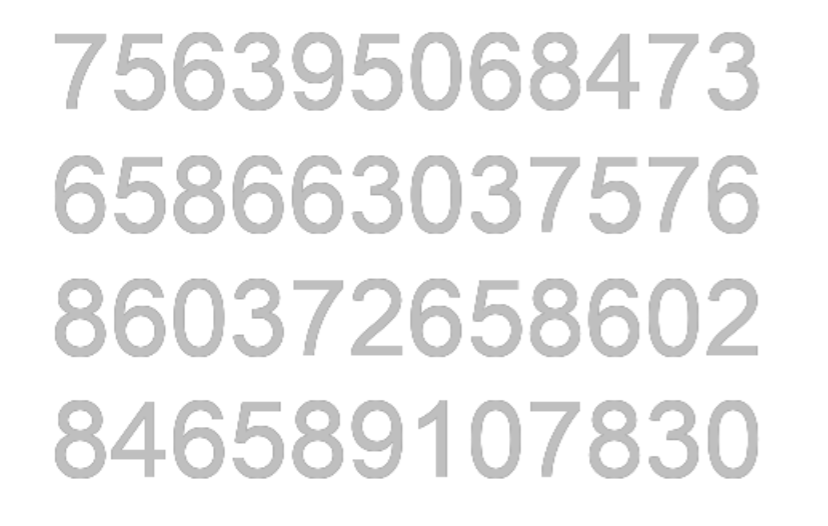 



*Count the 3s with colour highlight — the 3s jump out instantly (iconic memory) [ FIGURE 4.3 — p.103 ]*

> 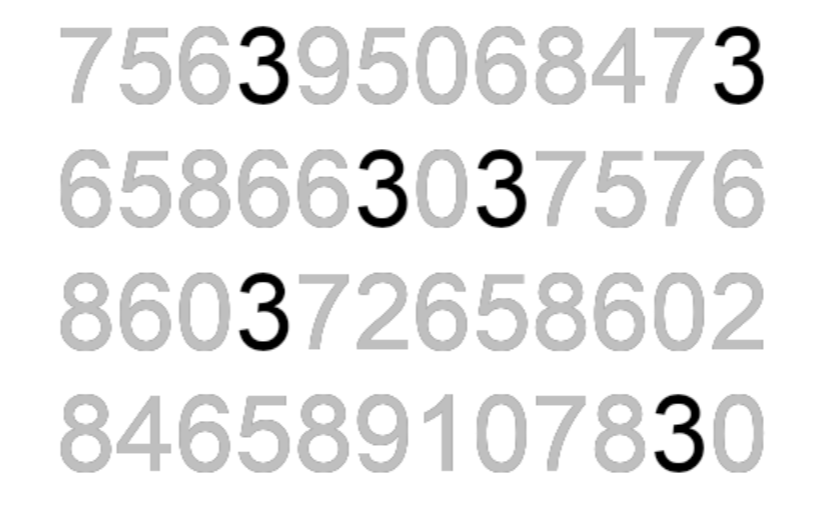 



*All pre-attentive attributes illustrated: colour, size, orientation, shape, added marks [ FIGURE 4.4 — p.104 ]*

> 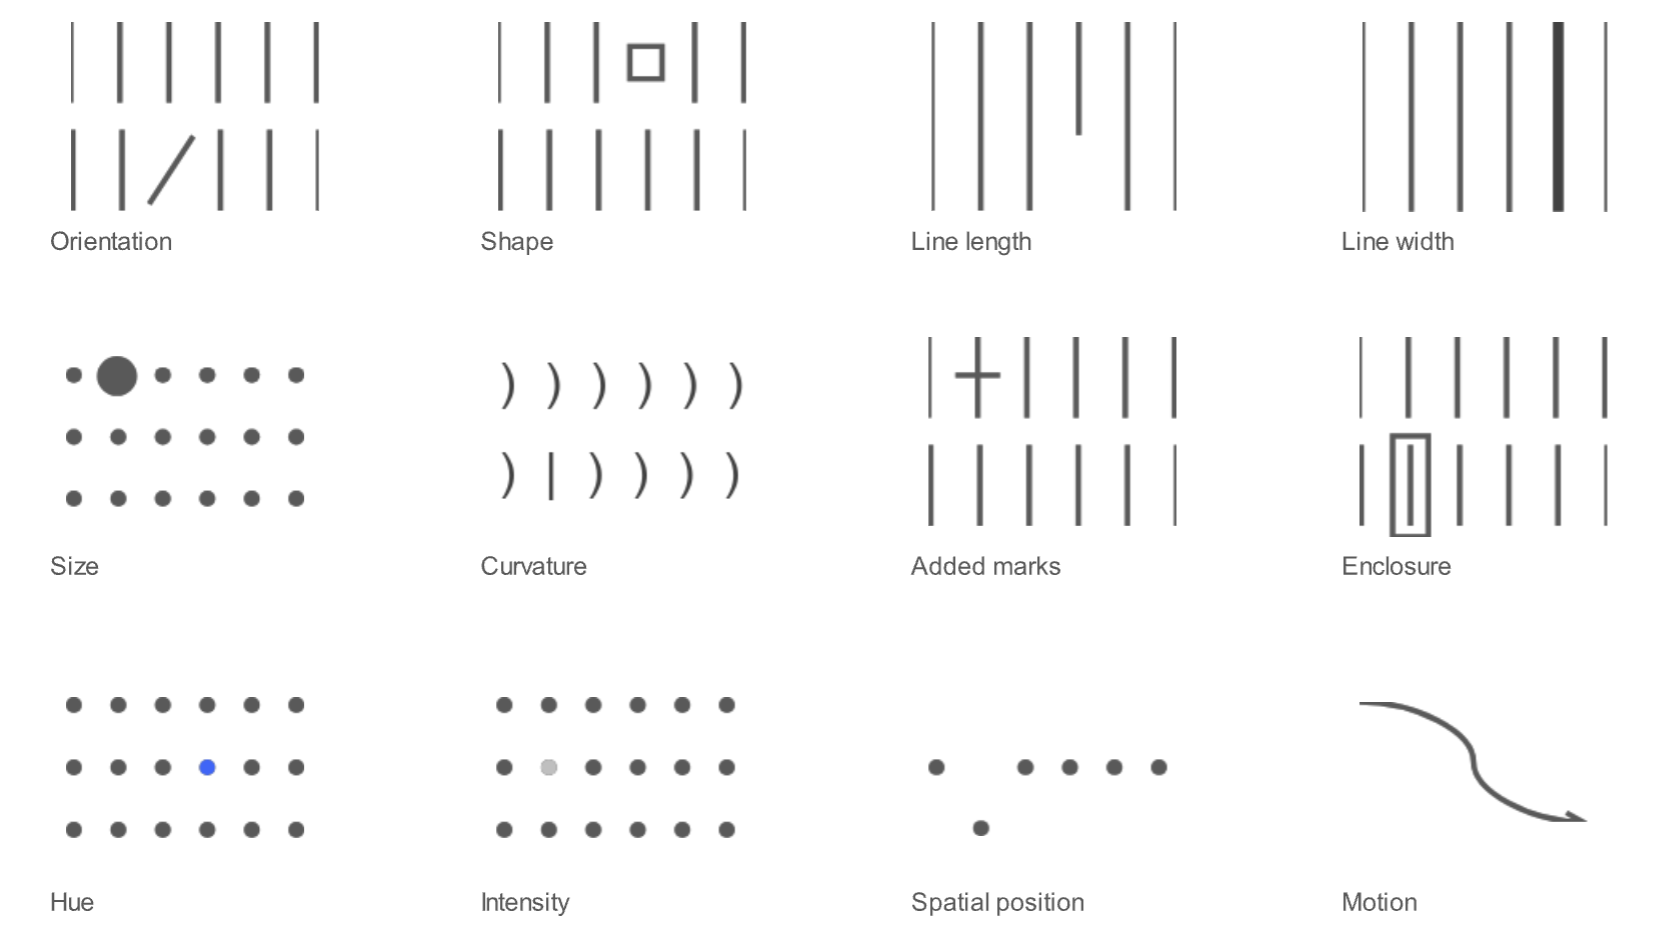  



### Colour — the most powerful and most abused

> 💡 **It is easy to spot a hawk in a sky full of pigeons. But as the variety of birds increases, the hawk becomes harder to locate. Colour only works when used sparingly. One bold colour among grey is a hawk. Ten colours are ten pigeons**



*Rainbow rank table — eyes dart randomly, no clear signal [ FIGURE 4.15 — p.118 ]*

> 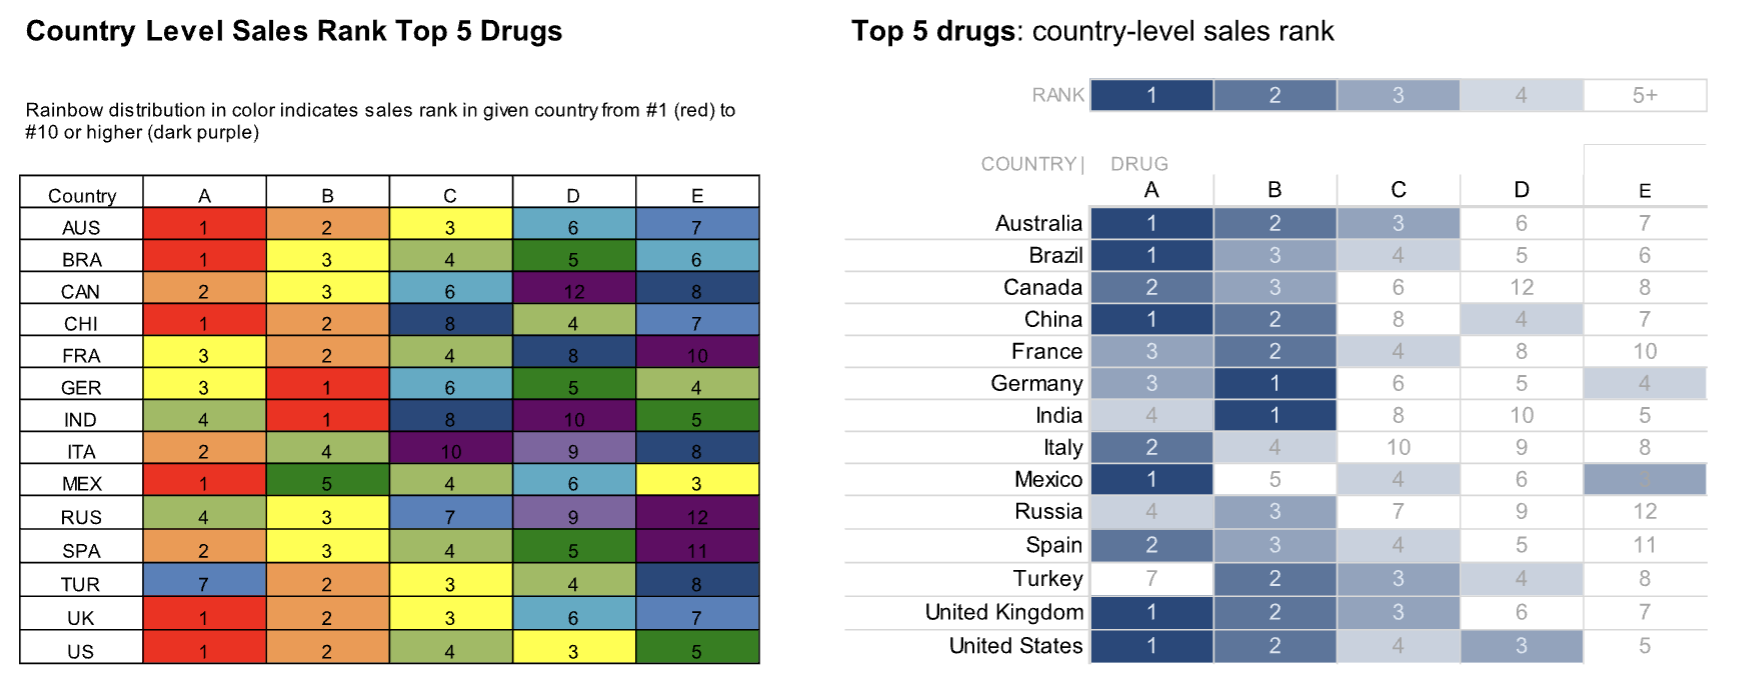 


*Strategic colour: brand colour / bold black / complementary colour approaches [ FIGURE 4.16 — p.124 ]*

> 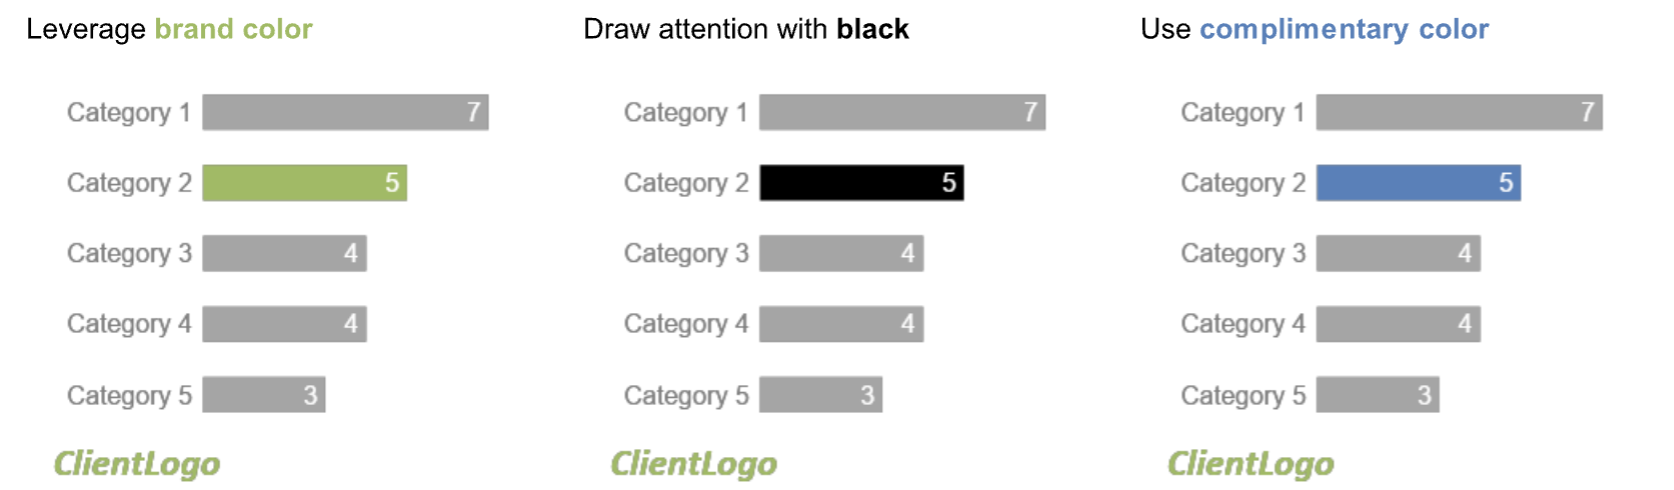



**Design rule:**
- Design everything in shades of **grey** first
- Then choose **one bold colour** for what matters
- Everything else stays grey — it is context, not message


---
## Design Principles - Part II: Scatter & Bubble Design

**When to use a scatter plot:**
- Relationship between two continuous variables
- Looking for correlation, clusters, or outliers

**When to use a bubble chart:**
- Same as scatter, but you have a **third numerical variable** to encode as size
- Size should be on a meaningful scale (set `size_max` to control)

**Scatter design rules:**
- Always ask: is the relationship actually meaningful, or spurious? 
- Remember: correlation IS NOT causation
- Add a reference line (average, trend) to give context
- Colour should encode a categorical variable — not continuous data
- Label outliers or notable points directly, not every point
- Beware overplotting (many overlapping dots) — use opacity


---
## Let's Code Some Examples 💻 


In [1]:
import pandas as pd
import plotly.express as px

# Dataset: Gapminder 2007 — GDP, Life Expectancy, Population by Country

df = px.data.gapminder(year=2007)
print(f"Loaded: {len(df)} rows")
print(df.head())

Loaded: 142 rows
        country continent  year  lifeExp       pop     gdpPercap iso_alpha  \
11  Afghanistan      Asia  2007   43.828  31889923    974.580338       AFG   
23      Albania    Europe  2007   76.423   3600523   5937.029526       ALB   
35      Algeria    Africa  2007   72.301  33333216   6223.367465       DZA   
47       Angola    Africa  2007   42.731  12420476   4797.231267       AGO   
59    Argentina  Americas  2007   75.320  40301927  12779.379640       ARG   

    iso_num  
11        4  
23        8  
35       12  
47       24  
59       32  


### Example 1 — Basic scatter: GDP vs Life Expectancy

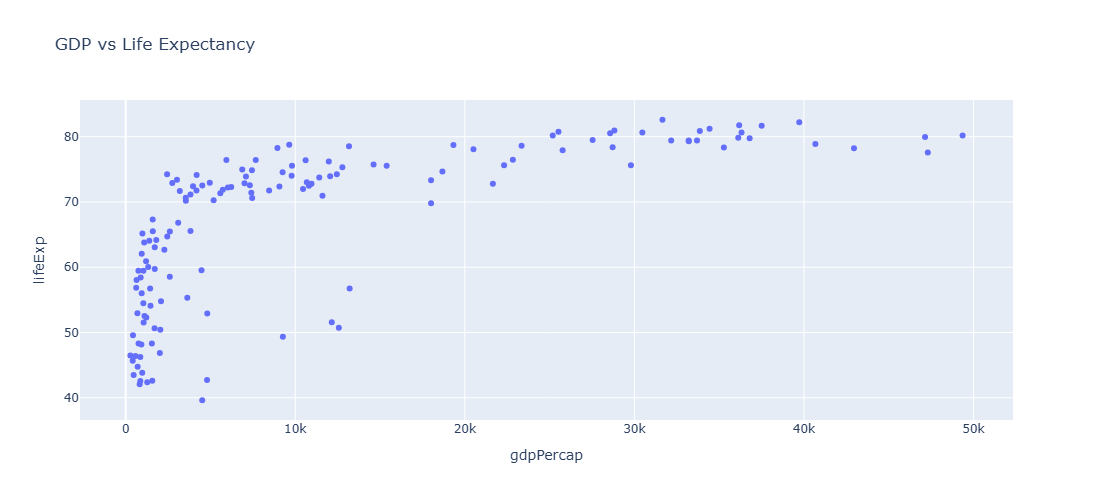

In [2]:

fig = px.scatter(data_frame=df, x='gdpPercap', y='lifeExp',
                 title='GDP vs Life Expectancy', height=500)
fig.show()


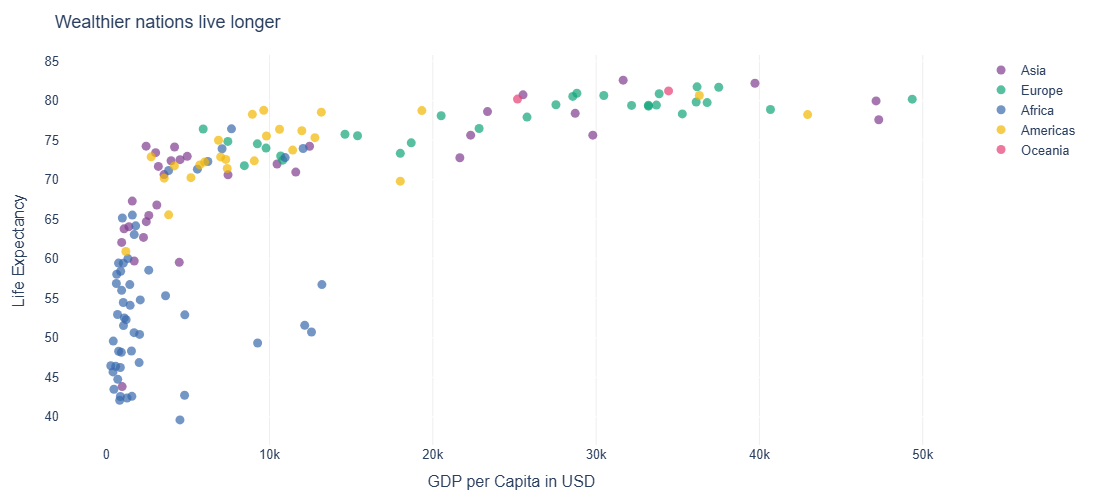

In [3]:
# Let's improve it!!
fig = px.scatter(
    data_frame=df, x='gdpPercap', y='lifeExp',
    color='continent',                      # colour encodes category (continent)
    hover_name='country',                   # hover shows country name
    labels={'gdpPercap': 'GDP per Capita in USD',
            'lifeExp': 'Life Expectancy',
            'continent': ''},
    color_discrete_sequence=px.colors.qualitative.Bold  # plotly express 
)
fig.update_layout(
    title='Wealthier nations live longer',
    plot_bgcolor='white', paper_bgcolor='white',
    font=dict(family='Arial', size=13),
    xaxis=dict(showgrid=True, gridcolor='#EEEEEE'),
    margin=dict(l=60, r=40, t=55, b=40), height=500
)

fig.update_traces(marker=dict(size=9, opacity=0.7))
fig.show()



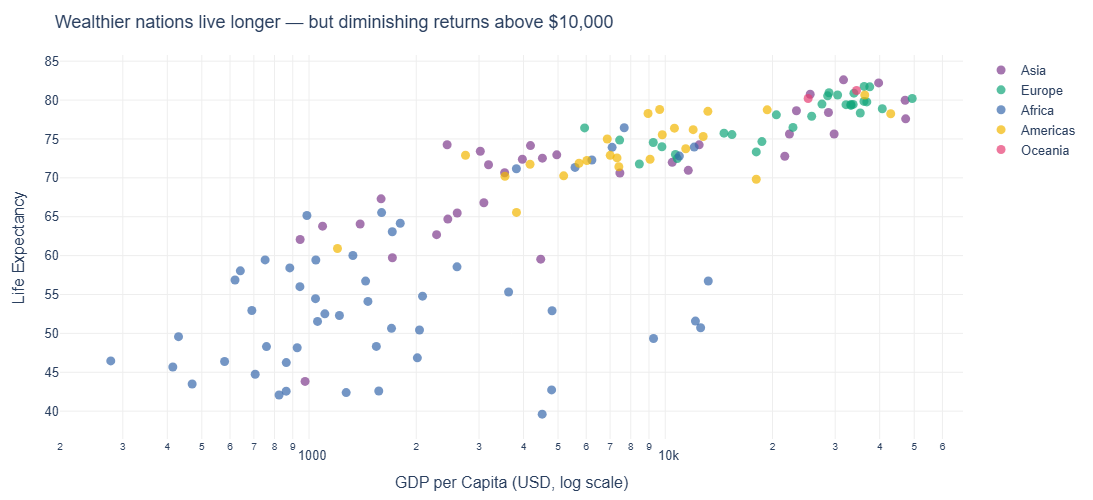

In [4]:
# Let's improve it further!!

fig = px.scatter(
    data_frame=df, x='gdpPercap', y='lifeExp',
    color='continent',                     
    hover_name='country',                 
    log_x=True,                             # log scale: wealth is non-linear
    labels={'gdpPercap': 'GDP per Capita (USD, log scale)',
            'lifeExp': 'Life Expectancy',
            'continent': ''},
    color_discrete_sequence=px.colors.qualitative.Bold
)
fig.update_layout(
    title='Wealthier nations live longer — but diminishing returns above $10,000',
    plot_bgcolor='white', paper_bgcolor='white',
    font=dict(family='Arial', size=13),
    yaxis=dict(gridcolor='#EEEEEE'),
    xaxis=dict(showgrid=True, gridcolor='#EEEEEE'),
    margin=dict(l=60, r=40, t=55, b=40), height=500
)
fig.update_traces(marker=dict(size=9, opacity=0.7))
fig.show()

### Example 2 — Bubble chart: add population as size

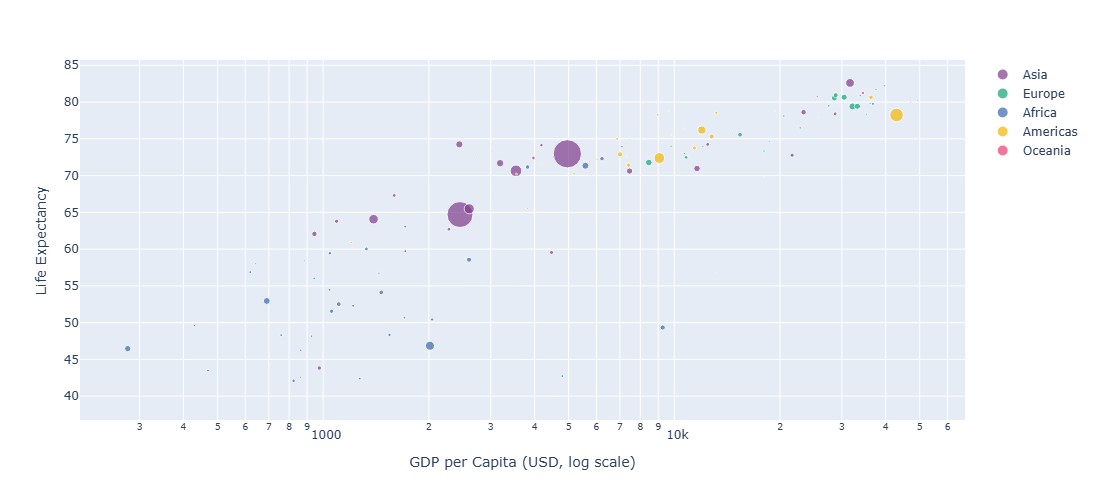

In [5]:

fig = px.scatter(data_frame=df, x='gdpPercap', y='lifeExp',
                 size='pop', color='continent',                    
                 hover_name='country',                 
                 log_x=True,                             # log scale: wealth is non-linear
                 labels={'gdpPercap': 'GDP per Capita (USD, log scale)', 'lifeExp': 'Life Expectancy', 'continent': ''},
                 color_discrete_sequence=px.colors.qualitative.Bold, height=500)

fig.show()


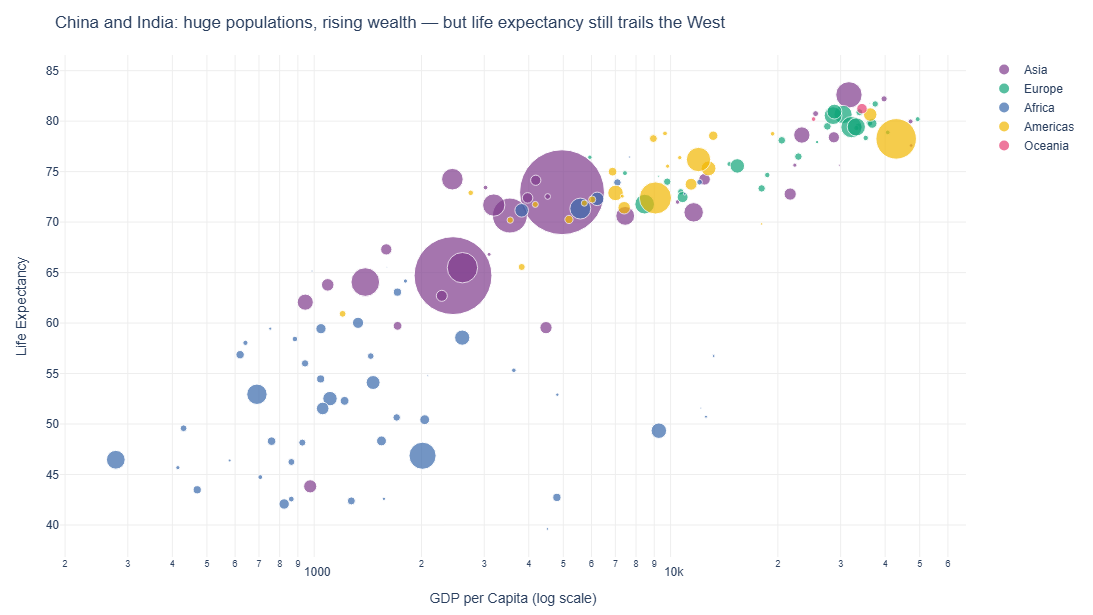

In [6]:
# Let's improve it

fig = px.scatter(
    data_frame=df, x='gdpPercap', y='lifeExp',
    size='pop',
    color='continent',
    hover_name='country',
    log_x=True,
    size_max=60,                            # cap bubble size so small countries still visible
    labels={'gdpPercap': 'GDP per Capita (log scale)', 'lifeExp': 'Life Expectancy', 'pop': 'Population', 'continent': ''},
    color_discrete_sequence=px.colors.qualitative.Bold,
    custom_data=['country', 'pop'],
    opacity=0.7
)

# Improve hover: show formatted population using HTML
fig.update_traces(
    hovertemplate='<b>%{hovertext}</b><br>'
                  'GDP per capita: $%{x:,.0f}<br>'
                  'Life expectancy: %{y:.1f} yrs<br>'
                  'Population: %{customdata[1]:,.0f}')

fig.update_layout(
    title='China and India: huge populations, rising wealth — but life expectancy still trails the West',
    plot_bgcolor='white', paper_bgcolor='white',
    font=dict(family='Arial', size=12),
    yaxis=dict(gridcolor='#EEEEEE'),
    xaxis=dict(gridcolor='#EEEEEE'),
    margin=dict(l=60, r=40, t=55, b=40),
    height=600, width=1150
)
fig.show()


In [7]:
px.colors.qualitative.Bold[0]

'rgb(127, 60, 141)'

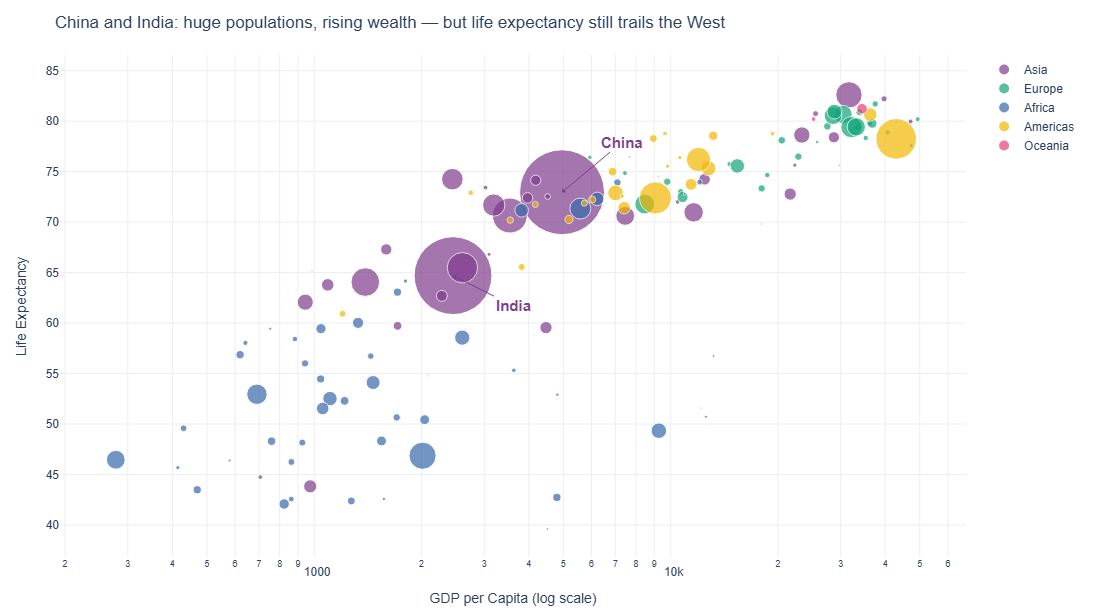

In [8]:
# let's improve it further!

# add annotation to highlight the insight
import math

for country, ax, ay in [('China', 60, -50), ('India', 60, 30)]:
    row = df[df['country'] == country].iloc[0]
    fig.add_annotation(
        x=math.log10(row['gdpPercap']), y=row['lifeExp'],
        text=f'<b>{country}</b>', showarrow=True, arrowcolor='rgb(127, 60, 141)',
        arrowhead=1, ax=ax, ay=ay,
        font=dict(size=15, family='Arial', color='rgb(127, 60, 141)')
    )
    
fig.show()

### Example 3 — Grey + highlight on scatter: tell ONE story - The Inequality Story

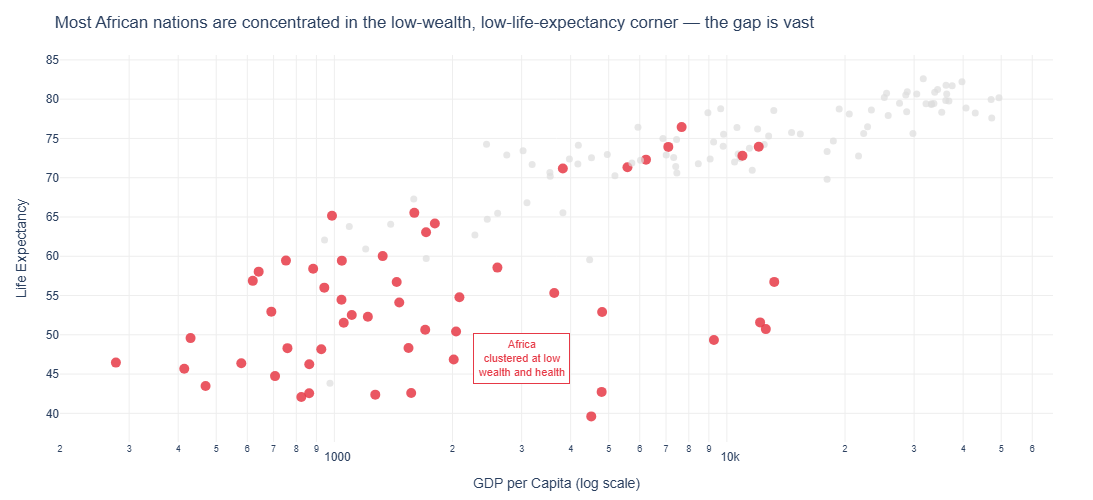

In [9]:


highlight_continent = 'Africa'
colour_map = {c: ('#E63946' if c == highlight_continent else '#DDDDDD') for c in df['continent'].unique()}

fig = px.scatter(
    data_frame=df,
    x='gdpPercap', y='lifeExp',
    color='continent',
    color_discrete_map=colour_map,
    hover_name='country',
    log_x=True,
    labels={'gdpPercap': 'GDP per Capita (log scale)', 'lifeExp': 'Life Expectancy', 'continent': ''},
    title='Most African nations are concentrated in the low-wealth, low-life-expectancy corner — the gap is vast'
)

fig.update_traces(
    showlegend=False,
    hovertemplate='<b>%{hovertext}</b><extra></extra>'
)
fig.update_traces(
    selector=dict(name=highlight_continent),
    marker=dict(size=10, opacity=0.85)
)
fig.update_traces(
    selector=lambda t: t.name != highlight_continent,
    marker=dict(size=7, opacity=0.7)
)

fig.add_annotation(
    x=math.log10(3000), y=47,
    text='Africa<br>clustered at low<br>wealth and health',
    showarrow=False,
    font=dict(color='#E63946', size=11, family='Arial'),
    bgcolor='white', bordercolor='#E63946', borderwidth=1, borderpad=4
)

fig.update_layout(
    xaxis=dict(gridcolor='#EEEEEE'),
    yaxis=dict(gridcolor='#EEEEEE'),
    plot_bgcolor='white', paper_bgcolor='white',
    font=dict(family='Arial', size=12),
    margin=dict(l=60, r=40, t=55, b=40), height=500
)

fig.show()
# TEACHING POINT: the same dataset, the same chart type, a completely different story
# depending on what you highlight. This is design as communication.

---
## Class Exercise 💪 💻


**Remember:**
- To highlight a group among multiple groups, grey all except the one you are highlighting
- Bubble size: always set `size_max` to prevent giant bubbles
- Log x-axis or y-axis for non-linear relationships
- Label outliers/notable points directly
